 **A) Быстрый обзор данных (Pandas)
• df.head(), df.tail(), df.shape.
• df.info() и df.describe() (отдельно покажите .describe(include="object") для строк).
• Проверки качества: isnull().sum(), поиск дубликатов, проверка адекватности типов данных.**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv('/content/netflix_titles.csv')
print("First dataset strings:")
display(df.head())
print("\nLast dataset strings:")
display(df.tail())
print(f"\nData format(strings, columns): {df.shape}")
print("Columns info:")
df.info()
print("\nNumeric columns statistics (release_year):")
display(df.describe())
print("\nStatistics for text (object) columns:")
display(df.describe(include="object"))
print("\nMissing values per column::")
print(df.isnull().sum())
duplicates = df.duplicated().sum()
print(f"\nNumber of full row duplicates: {duplicates}")

First dataset strings:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Last dataset strings:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...



Data format(strings, columns): (8807, 12)
Columns info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Numeric columns statistics (release_year):


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



Statistics for text (object) columns:


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4



Missing values per column::
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Number of full row duplicates: 0


**Б) Покажите стратегии dropna() и fillna(). Заполняйте средним, медианой, константой — и обязательно обоснуйте выбор текстовым комментарием.
• Отдельно покажите, как считаете моду (mode) и заполняете ею пропуски в категориальных колонках.**

In [ ]:
# Значения в данных колонках строчные, мы не можем заменить их средним или медианой,
#а также удаление их приведет к утрате большого количества числовых данных(>30%)
#заполняем константой 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# В категории выделяется явный лидер
country_mode = df['country'].mode()[0]
df['country'] = df['country'].fillna(country_mode)

# Так мы гарантируем, что не создадим новые типы рейтингов
rating_mode = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(rating_mode)

# Качество данных имеет значение при анализе контента по времени выхода
# <0.1% от числа строк
df.dropna(subset=['date_added'], inplace=True)

# <0.1% от числа строк
df.dropna(subset=['duration'], inplace=True)

print("\nMissing values per column after filling and dropping::")
print(df.isnull().sum())


Missing values per column after filling and dropping::
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


**C) Расширенная статистика
• Для числовых колонок выведите: min, max, mean, median, mode.
• Посчитайте percentile/quantile (например, 5, 25, 50, 75, 95 перцентили).
🧠 Самостоятельно изучите и посчитайте: дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis). Попробуйте объяснить, что они значат для ваших данных.**

In [ ]:
target_col = 'release_year'
min_val = df[target_col].min()
max_val = df[target_col].max()
mean_val = df[target_col].mean()
median_val = df[target_col].median()
mode_val = df[target_col].mode()[0]
percentiles = df[target_col].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
variance = df[target_col].var()
skewness = df[target_col].skew()
kurtosis = df[target_col].kurt()
print(f"Analysis for '{target_col}':")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")
print("-" * 30)
print(f"Variance (Дисперсия): {variance:.2f}")
print(f"Skewness (Асимметрия): {skewness:.2f}")
print(f"Kurtosis (Эксцесс): {kurtosis:.2f}")
print("-" * 30)
print("Percentiles:")
print(percentiles)

Analysis for 'release_year':
Min: 1925
Max: 2021
Mean: 2014.18
Median: 2017.0
Mode: 2018
------------------------------
Variance (Дисперсия): 77.85
Skewness (Асимметрия): -3.45
Kurtosis (Эксцесс): 16.23
------------------------------
Percentiles:
0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64


 **D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)
• Сделайте кодирование категорий: OneHotEncoder (или pd.get_dummies) — обязательно.
• Если уместно: Label Encoding или Target Encoding. Покажите датафрейм до/после.
 🧠 Самостоятельно изучите: попробуйте применить Feature Hashing (Hashing Encoder) для признаков с большим числом уникальных значений.
 🧠 Генерация новых фич: создайте 2-3 новых признака. Например, перемножьте/поделите две существующие колонки, вытащите месяц из даты или сгруппируйте редкие категории в одну "Other".**

In [ ]:
print('Dataframe before feature engineering:\n')
display(df.head())
# One-hot encoder: Превращаю type в type_Movie и type_TvShow (числовые признаки)
df['type_cat'] = df['type']
df = pd.get_dummies(df, columns=['type'], prefix='type')

# Возраст контента перед попаданием на сервис
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['content_age'] = df['year_added'] - df['release_year']

# Основная страна производства
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0] if x != 'Unknown' else 'Unknown')

# Считаем количество актеров (размер каста)
df['cast_size'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))

# Количество жанров
df['num_genres'] = df['listed_in'].apply(lambda x: len(x.split(',')))

display(df.head())


Dataframe before feature engineering:



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type_cat,type_Movie,type_TV Show,year_added,content_age,primary_country,cast_size,num_genres
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Movie,True,False,2021,1,United States,0,1
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Show,False,True,2021,0,South Africa,19,3
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,TV Show,False,True,2021,0,United States,9,3
3,s4,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",TV Show,False,True,2021,0,United States,0,2
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,TV Show,False,True,2021,0,India,8,3


**Е) Визуализация (Самая красивая часть!)
Используем ВСЕ ТРИ библиотеки (matplotlib, seaborn, plotly). Не для галочки, а со смыслом!
Распределения: гистограммы / KDE.
Scatter plot — ищем зависимости между числами.
Box plot (ящик с усами) — ищем аномалии/выбросы.
Bar/count plot для категорий.
Heatmap корреляций (напишите короткий вывод, какие колонки сильно коррелируют). (По желанию: pairplot, violinplot, интерактивный график Plotly с параметром hover_data).**

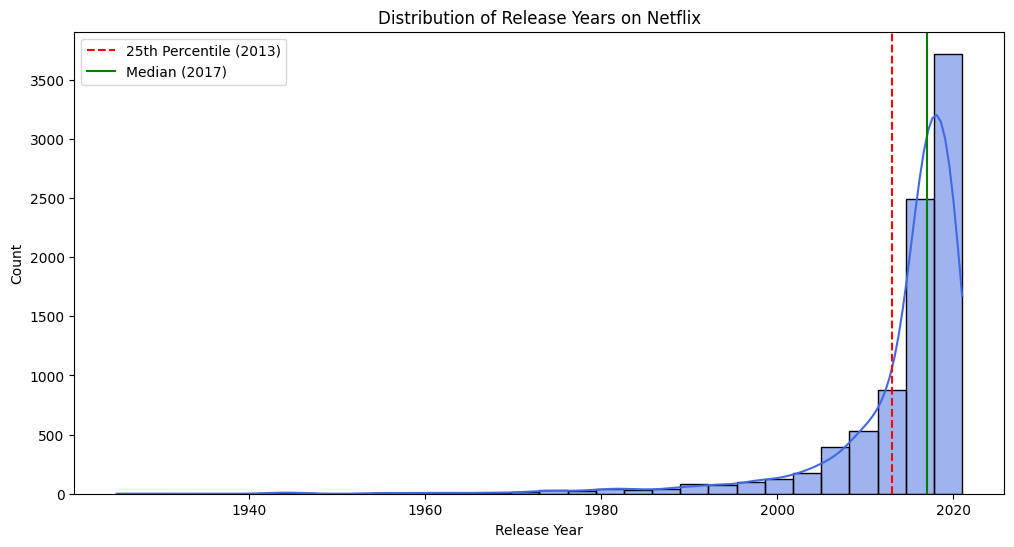

/tmp/ipykernel_559/593441014.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['release_year'], palette='Set3')


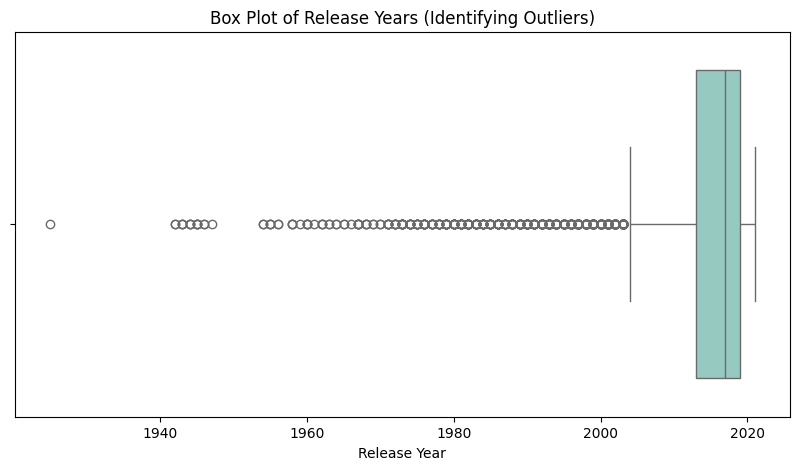

/tmp/ipykernel_559/593441014.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type_cat', palette='viridis')


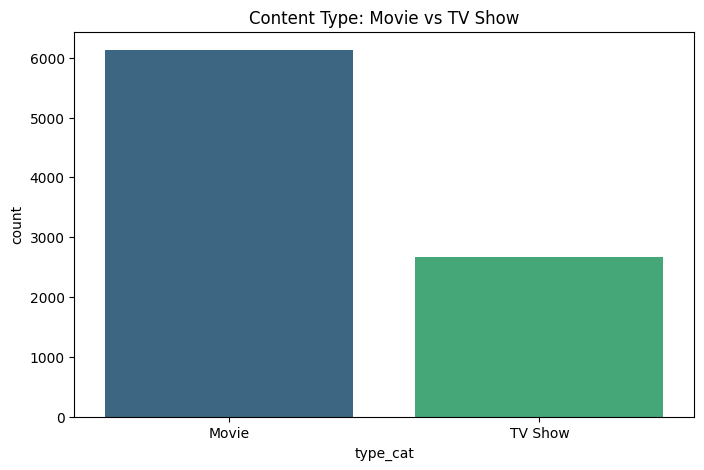

/tmp/ipykernel_559/593441014.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


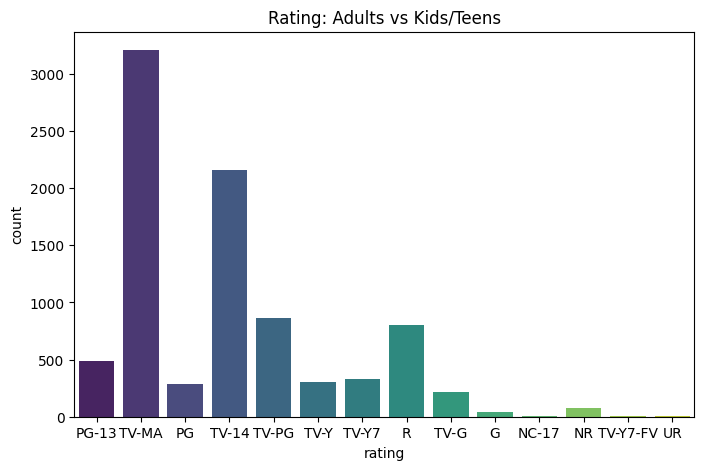

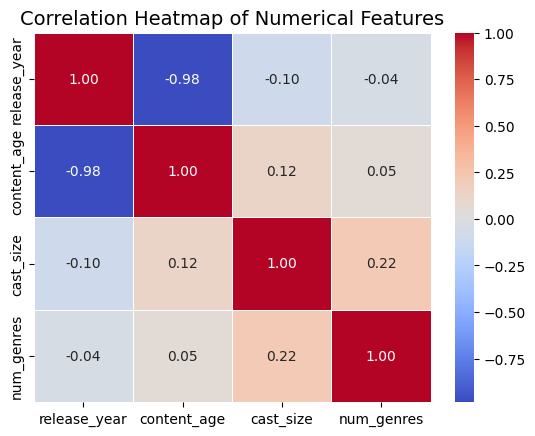

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.figure(figsize=(12, 6))
# Гистограмма с линией распределения (KDE)
sns.histplot(df['release_year'], kde=True, bins=30, color='royalblue')

# Отмечаем перцентили
plt.axvline(df['release_year'].quantile(0.25), color='red', linestyle='--', label='25th Percentile (2013)')
plt.axvline(df['release_year'].median(), color='green', linestyle='-', label='Median (2017)')

plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend()
plt.show()

# Ящик с усами
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['release_year'], palette='Set3')
plt.title('Box Plot of Release Years (Identifying Outliers)')
plt.xlabel('Release Year')
plt.show()

# Сравнение категорий с Bar plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type_cat', palette='viridis')
plt.title('Content Type: Movie vs TV Show')
plt.show()
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Rating: Adults vs Kids/Teens')
plt.show()


# Heatmap для выявления корреляции признаков
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'uint8', float]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()



 **F) Итоговые выводы (Markdown)
В конце ноутбука напишите:
• 7–12 буллетов «Что я понял про датасет».
• 3–5 гипотез/наблюдений (про влияние категорий на таргет, природу выбросов и т.д.).
• Что бы вы сделали дальше (какую модель взяли бы, что предсказывали).
• Маленький блок: «Какие подсказки брал у AI и что в итоге проверял/дописывал руками».**

*Что я понял про датасет*

- В датасете множественные пропуски в категориях director, cast и country
- Преобладание в признаках object типа над числовыми (int64 только у released year)
- Гистограмма и box plot, построенные по released year, показывают высокую плотность контента за 5 последних лет, это подтверждает и median в 2017 году
- United States абсолютный лидер в категории country
- Большой перевес Movie над Tv Show в type_cat
- Преобладание Adults рейтингов(PG-13 и TV-MA над подростковыми и детскими)
- Заметна рост значений признака cast_size при росте num_genres


*Гипотезы/наблюдения*

- Фильмы с большим количеством жанров (num_genres) имеют более обширный актерский состав (cast_size), так как требует большего числа типажей
- Политика Netflix основана на выпуске новинок, поэтому большая часть контента выпущена в последние годы
- Netflix делает ставку на взрослую аудиторию и фильмы, что видно по raiting и type_cat

*Что бы вы сделали дальше (какую модель взяли бы, что предсказывали).*
- Система рекомендаций:
Использование моделей для предсказания того, что пользователь захочет посмотреть следующим,поиск сходств в жанрах, актерском составе и других признаках
- Прогнозирование рейтинга:
Предсказание рейтинга фильма или сериала по признакам еще до его выхода

*«Какие подсказки брал у AI и что в итоге проверял/дописывал руками»*

У AI брал теоретические материалы, относящиеся к теории по теме машинного обучения, а также использующимся библиотекам. Для проверки правильности выполнения заданий и выдвинутых гипотез также использовался ии ассистент